In [ ]:
from google.colab import files
uploaded = files.upload()

Saving q1_heart_disease.csv to q1_heart_disease.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('q1_heart_disease.csv')

# empty values ko NaN me convert
df.replace('', np.nan, inplace=True)

df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


Dataset loaded successfully. Some missing values are present.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

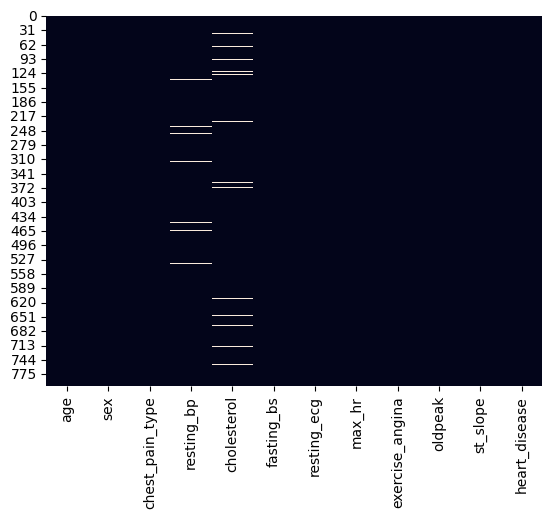

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

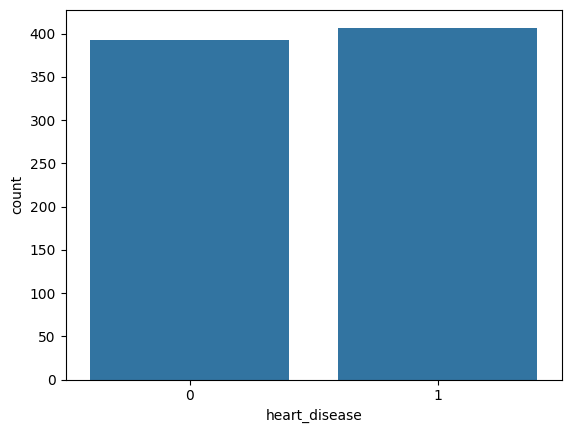

In [ ]:
sns.countplot(x='heart_disease', data=df)
plt.show()

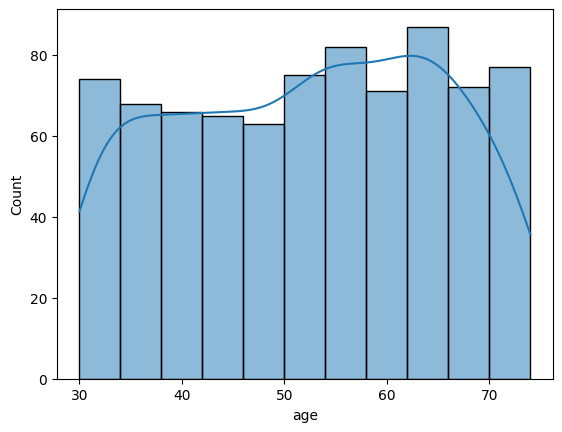

In [ ]:
sns.histplot(df['age'], kde=True)
plt.show()

Missing values are present in resting_bp and cholesterol columns.
Target variable shows distribution of heart disease cases.
Age distribution appears approximately normal.

In [ ]:
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

/tmp/ipykernel_10095/2285452925.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
/tmp/ipykernel_10095/2285452925.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.775


Missing values were handled using median imputation.
Categorical variables were converted into numerical using one-hot encoding.
Data was split into training and testing sets.
Logistic Regression model was trained.
Model accuracy was evaluated using accuracy score.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[56 19]
 [17 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76        75
           1       0.78      0.80      0.79        85

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.78      0.77       160



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.775


In [ ]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
age,0.189422
resting_bp,0.115298
oldpeak,0.111418
cholesterol,0.111091
max_hr,0.105636
exercise_angina,0.083817
chest_pain_type_non_anginal,0.081095
chest_pain_type_atypical_angina,0.060073
st_slope_flat,0.027047
chest_pain_type_typical_angina,0.026828


Confusion matrix was used to evaluate model performance.
Classification report provides precision, recall and F1-score.
Random Forest model was applied for better performance.
Feature importance was analyzed to identify key factors affecting heart disease.

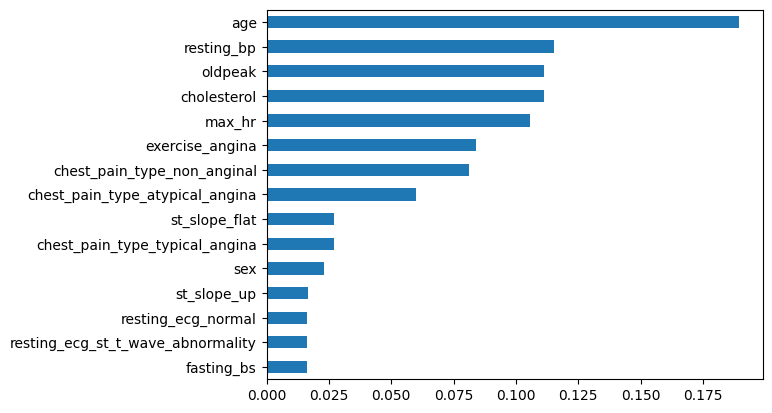

In [ ]:
importance.sort_values().plot(kind='barh')
plt.show()